In [70]:
import pandas as pd
import numpy as np
from pathlib import Path
from AutomatedCellAnalysis.displaydata import displaydata
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [73]:
base_path = Path('C:\\Users\\thinkBookUser\\Desktop\\Screening_Data_Analyzed')
data1 = pd.read_csv(Path(base_path,'2019','11','07','chemical','results','all_results.csv'))
data2 = pd.read_csv(Path(base_path,'2020','02','06','chemical','results','all_results.csv'))
all_data = pd.concat([data1,data2])
all_data = all_data.replace([np.inf, -np.inf], np.nan)
fit_noerrors = all_data[all_data['error']==0] # <<<<<<< the data that passed all fitting hurdles!
fit_hasdarkframe = all_data[all_data['error']==8]  # <<<<<<< the data that was corrected for "dark frame", but otherwise passed all hurdles!
errorfree_data = pd.concat([fit_noerrors,fit_hasdarkframe])  # <<<<<<< We only look at the errorfree data!

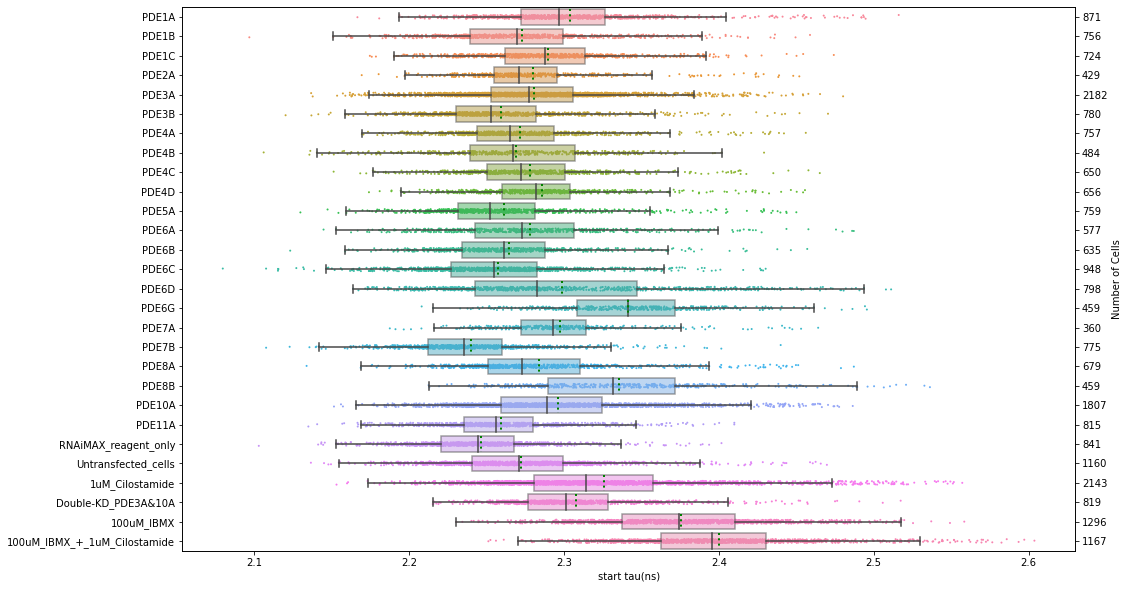

In [74]:
# this makes the boxplot figure of start value-distribution for each condition
fig, ax = displaydata(errorfree_data,'start tau(ns)')
ax.yaxis.set_label_text("")
fig.set_size_inches([16, 10])

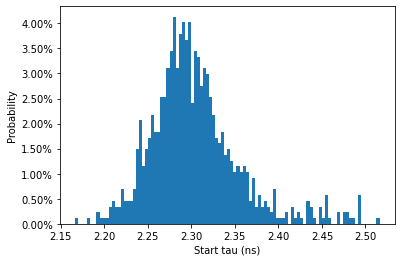

In [86]:
# makes the 100-bin histogram of the initial lifetime values distribution
data = errorfree_data[errorfree_data['condition']=='PDE1A']['start tau(ns)'] # select condition here!!!
plt.hist(data, bins=100, weights=np.ones(len(data))/len(data))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel('Start tau (ns)')
plt.ylabel('Probability')
plt.show()

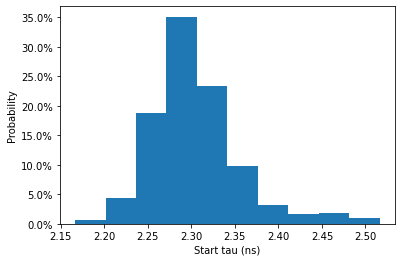

In [85]:
# same plot, but less bins, more intuitive to see that most data falls into the middle 4 bins
# eg for PDE1A: 18%+35%+23%+10%=86% lies between 2.23 and 2.37
# very few cells have a baseline below 2.2 ns!
# about 10% of cells have a high-initial lifetime (over 2.4 ns)
plt.hist(data, bins=10, weights=np.ones(len(data))/len(data))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel('Start tau (ns)')
plt.ylabel('Probability')
plt.show()

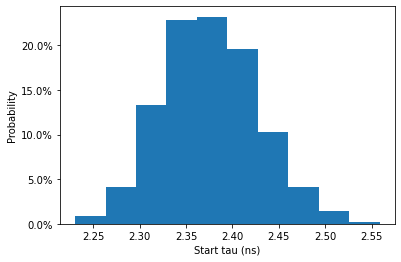

In [77]:
# here I took a IBMX pretreated condtion to demonstrate how the historam shifts to the right
data2 = errorfree_data[errorfree_data['condition']=='100uM_IBMX']['start tau(ns)']
plt.hist(data2, bins=10, weights=np.ones(len(data2))/len(data2))
plt.xlabel('Start tau (ns)')
plt.ylabel('Probability')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

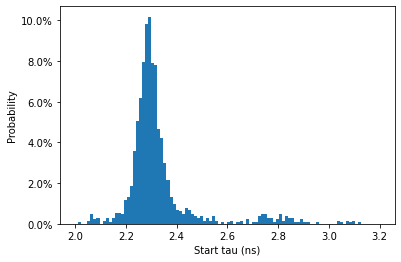

In [82]:
# NB: all_data (also includes those cells that didnt qualify for a good fit)
# Note that there are more cells with initially high starting-values
data = all_data[all_data['condition']=='PDE1A']['start tau(ns)'] # select condition here!!!
plt.hist(data, bins = 100, weights=np.ones(len(data))/len(data), range = (2, 3.2))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel('Start tau (ns)')
plt.ylabel('Probability')
plt.show()